# DVC_data_filtered.csv — Exploratory Data Analysis

Same analysis as `data_analysis.ipynb`, run on a **filtered** extract of the deer–vehicle
collision (DVC) dataset:

* **States kept (9):** Connecticut, Maryland, Iowa, South Carolina, Wyoming, Texas, Kansas, Massachusetts, Georgia
* **Rows with missing exact coordinates removed** — every row here has both `Latitude` and `Longitude`.

Built from `DVC_data.csv` (1,012,465 rows) → `DVC_data_filtered.csv` (444,418 rows).

Questions answered:

1. Which **states** are included?
2. What **percent of rows have both Longitude and Latitude**? (100% by construction — kept as a check.)
3. Which **columns** have what **percent of values as NaN**?
4. Other data-quality and coverage findings worth knowing before modeling.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_rows', 120)
pd.set_option('display.width', 200)

CSV_PATH = 'DVC_data_filtered.csv'

# First column is the original 1-based row id from DVC_data.csv -> use as index.
# 'NA' strings (R-style) are parsed as NaN by pandas' default na_values.
df = pd.read_csv(CSV_PATH, index_col=0)
df.index.name = 'row_id'
print(f'{len(df):,} rows  x  {df.shape[1]} columns')
df.head()

444,418 rows  x  17 columns


,state,date_time,time.decimal,month,county_name,lat_CountyCentroid,long_CountyCentroid,doy,Latitude,Longitude,week,sunrise,sunrise.decimal,sunset,sunset.decimal,timezone,state_abbreviation
row_id,,,,,,,,,,,,,,,,,
164584,Wyoming,1994-01-01 02:30:00,2.5,1,uinta,41.287417,-110.547558,1,41.26533,-110.40593,53,1994-01-01 07:49:12,7.820000,1994-01-01 17:04:17,17.071389,Mountain,WY
164585,Wyoming,1994-01-01 18:00:00,18.0,1,goshen,42.086632,-104.353263,1,42.01107,-104.06850,53,1994-01-01 07:26:58,7.449444,1994-01-01 16:36:57,16.615833,Mountain,WY
164586,Wyoming,1994-01-02 04:00:00,4.0,1,lincoln,42.260476,-110.654163,2,43.14711,-111.03431,53,1994-01-02 07:52:49,7.880278,1994-01-02 17:02:26,17.040556,Mountain,WY
164587,Wyoming,1994-01-02 05:30:00,5.5,1,teton,43.932627,-110.589369,2,43.47965,-110.81205,53,1994-01-02 07:58:08,7.968889,1994-01-02 16:56:36,16.943333,Mountain,WY
164588,Wyoming,1994-01-02 18:18:00,18.3,1,teton,43.932627,-110.589369,2,43.53102,-110.73959,53,1994-01-02 07:58:08,7.968889,1994-01-02 16:56:36,16.943333,Mountain,WY


In [2]:
# Column inventory: dtype, non-null count, distinct values
info = pd.DataFrame({
    'dtype': df.dtypes.astype(str),
    'non_null': df.notna().sum(),
    'n_unique': df.nunique(dropna=True),
})
info

,dtype,non_null,n_unique
state,str,444418,9
date_time,str,444418,381174
time.decimal,float64,444418,1441
month,int64,444418,12
county_name,str,444418,596
lat_CountyCentroid,float64,444222,732
long_CountyCentroid,float64,444222,732
doy,int64,444418,366
Latitude,float64,444418,389369
Longitude,float64,444418,390390


## 1. States included

In [3]:
states = (df.groupby('state')
            .agg(records=('state', 'size'),
                 abbr=('state_abbreviation', 'first'),
                 n_counties=('county_name', 'nunique'),
                 first_date=('date_time', 'min'),
                 last_date=('date_time', 'max'))
            .sort_values('records', ascending=False))
states['pct_of_data'] = (states['records'] / len(df) * 100).round(2)

print(f"{df['state'].nunique()} states present:")
print(', '.join(sorted(df['state_abbreviation'].dropna().unique())))
states[['abbr', 'records', 'pct_of_data', 'n_counties', 'first_date', 'last_date']]

9 states present:
CT, GA, IA, KS, MA, MD, SC, TX, WY


,abbr,records,pct_of_data,n_counties,first_date,last_date
state,,,,,,
Kansas,KS,100031,22.51,105,2011-01-01 00:55:00,2021-12-01 04:31:00
Iowa,IA,76725,17.26,99,2011-01-01 16:47:00,2021-11-15 17:19:00
Georgia,GA,70801,15.93,160,2015-01-01 00:00:00,2021-12-07 21:45:00
Texas,TX,68498,15.41,255,2011-01-01 01:50:00,2020-12-31 22:51:00
Wyoming,WY,56596,12.73,24,1994-01-01 02:30:00,2020-12-31 19:15:00
Massachusetts,MA,38926,8.76,15,2002-01-01 05:45:00,2021-11-23 20:37:00
Maryland,MD,16618,3.74,23,2015-01-01 17:41:00,2021-06-30 23:06:00
South Carolina,SC,8692,1.96,47,2018-01-01 02:40:00,2021-11-23 19:45:00
Connecticut,CT,7531,1.69,8,2014-12-21 07:20:00,2021-10-18 16:20:00


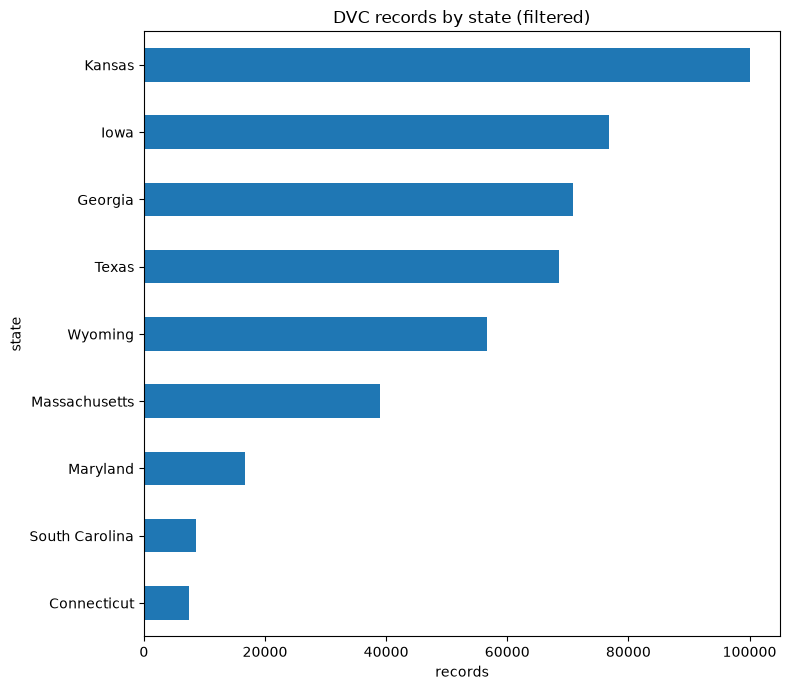

In [4]:
ax = states['records'].sort_values().plot.barh(figsize=(8, 7))
ax.set_xlabel('records')
ax.set_title('DVC records by state (filtered)')
plt.tight_layout()
plt.show()

## 2. Coordinate coverage — Latitude / Longitude

`Latitude` / `Longitude` are the **precise incident coordinates**. `lat_CountyCentroid` / `long_CountyCentroid` are a **fallback location** (the centroid of the county the record is attributed to).

In this filtered file every row has precise coordinates, so the "BOTH lat & lon present" figure below should be 100%.

In [5]:
n = len(df)
has_lat = df['Latitude'].notna()
has_lon = df['Longitude'].notna()
has_both = has_lat & has_lon
has_either = has_lat | has_lon
has_centroid = df['lat_CountyCentroid'].notna() & df['long_CountyCentroid'].notna()

print(f'Latitude present            : {has_lat.mean()*100:6.2f}%  ({has_lat.sum():,})')
print(f'Longitude present           : {has_lon.mean()*100:6.2f}%  ({has_lon.sum():,})')
print(f'BOTH lat & lon present      : {has_both.mean()*100:6.2f}%  ({has_both.sum():,})')
print(f'Either lat or lon present   : {has_either.mean()*100:6.2f}%  ({has_either.sum():,})')
print(f'Only one of the two present : {(has_either & ~has_both).sum():,} rows'
      f'  (lat-only {(has_lat & ~has_lon).sum():,}, lon-only {(has_lon & ~has_lat).sum():,})')
print()
print(f'County-centroid coords present : {has_centroid.mean()*100:6.2f}%')
print(f'Some usable location (precise OR centroid): {(has_both | has_centroid).mean()*100:6.2f}%')
print(f'NO location at all              : {(~has_both & ~has_centroid).sum():,} rows'
      f'  ({(~has_both & ~has_centroid).mean()*100:.2f}%)')

Latitude present            : 100.00%  (444,418)
Longitude present           : 100.00%  (444,418)
BOTH lat & lon present      : 100.00%  (444,418)
Either lat or lon present   : 100.00%  (444,418)
Only one of the two present : 0 rows  (lat-only 0, lon-only 0)

County-centroid coords present :  99.96%
Some usable location (precise OR centroid): 100.00%
NO location at all              : 0 rows  (0.00%)


In [6]:
# Precise-coordinate coverage by state (100% everywhere here, by construction)
cov = (df.assign(has_both=has_both, has_centroid=has_centroid)
         .groupby('state')
         .agg(records=('state', 'size'),
              pct_precise_latlon=('has_both', lambda s: round(s.mean()*100, 1)),
              pct_county_centroid=('has_centroid', lambda s: round(s.mean()*100, 1)))
         .sort_values('pct_precise_latlon'))
cov

,records,pct_precise_latlon,pct_county_centroid
state,,,
Connecticut,7531,100.0,100.0
Georgia,70801,100.0,99.9
Iowa,76725,100.0,100.0
Kansas,100031,100.0,100.0
Maryland,16618,100.0,100.0
Massachusetts,38926,100.0,100.0
South Carolina,8692,100.0,99.7
Texas,68498,100.0,100.0
Wyoming,56596,100.0,99.9


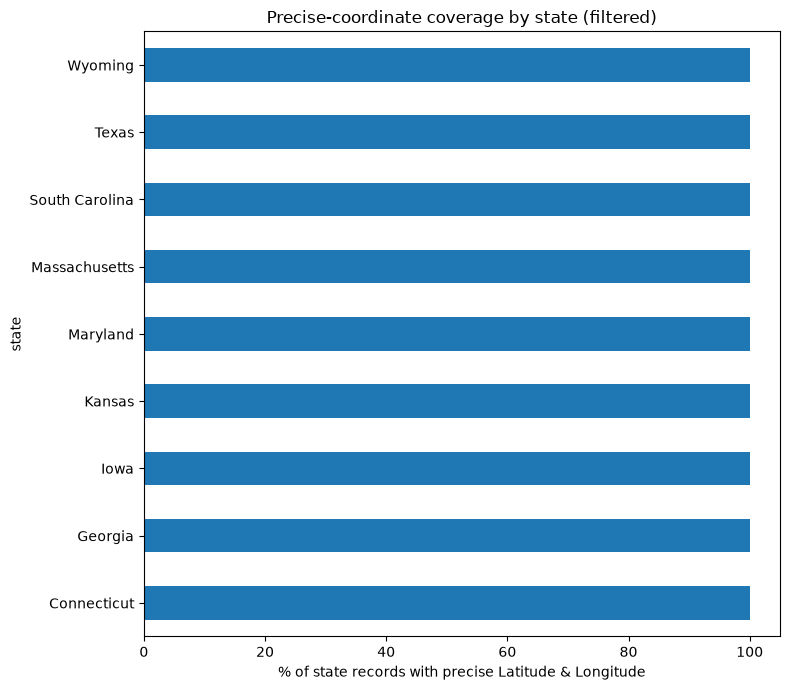

In [7]:
ax = cov['pct_precise_latlon'].plot.barh(figsize=(8, 7))
ax.set_xlabel('% of state records with precise Latitude & Longitude')
ax.set_title('Precise-coordinate coverage by state (filtered)')
plt.tight_layout()
plt.show()

## 3. Missing data (NaN) by column

In [8]:
nan_pct = (df.isna().mean() * 100).round(3)
nan_tbl = pd.DataFrame({
    'n_missing': df.isna().sum(),
    'pct_missing': nan_pct,
}).sort_values('pct_missing', ascending=False)
nan_tbl

,n_missing,pct_missing
long_CountyCentroid,196,0.044
lat_CountyCentroid,196,0.044
state,0,0.000
date_time,0,0.000
time.decimal,0,0.000
county_name,0,0.000
month,0,0.000
doy,0,0.000
Latitude,0,0.000
Longitude,0,0.000


C:\Users\geeta\AppData\Local\Temp\ipykernel_3212\2165144302.py:8: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


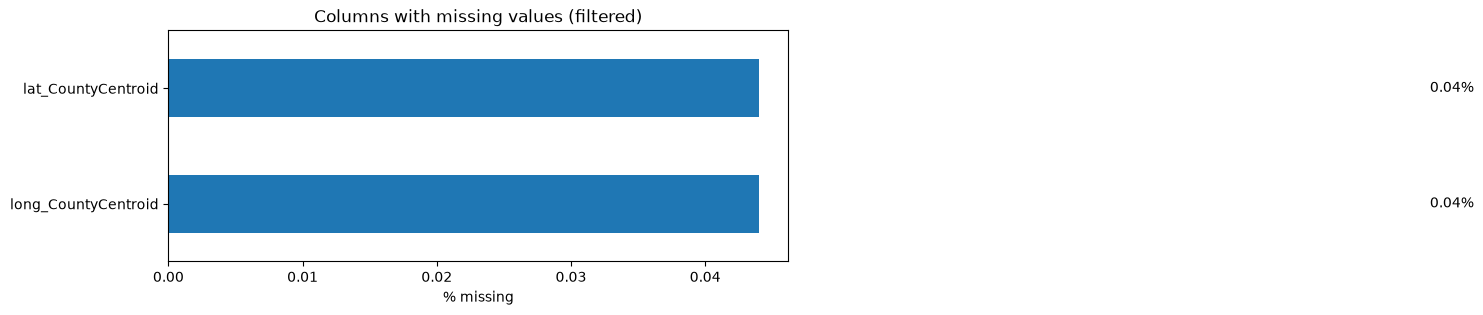

In [9]:
missing = nan_tbl[nan_tbl['pct_missing'] > 0]
if len(missing):
    ax = missing['pct_missing'].sort_values().plot.barh(figsize=(8, 3))
    ax.set_xlabel('% missing')
    ax.set_title('Columns with missing values (filtered)')
    for i, v in enumerate(missing['pct_missing'].sort_values()):
        ax.text(v + 0.05, i, f'{v:.2f}%', va='center')
    plt.tight_layout()
    plt.show()
else:
    print('No columns have missing values in the filtered dataset.')

**Takeaway:** `Latitude` / `Longitude` are now 0% missing (the filter guaranteed it). Any remaining NaNs are confined to `lat_CountyCentroid` / `long_CountyCentroid` (rows tagged `STATE_CENTROID`). Every other column is 100% populated.

## 4. Coordinate quality (of the rows that *do* have coordinates)

In [10]:
c = df.loc[has_both, ['state', 'Latitude', 'Longitude']].copy()
# Plausible bounds for the US (incl. Alaska)
in_bounds = c['Latitude'].between(18, 72) & c['Longitude'].between(-170, -60)
print(f'Rows with both coords            : {len(c):,}')
print(f'Within plausible US lat/lon box  : {in_bounds.mean()*100:.2f}%  ({in_bounds.sum():,})')
print(f'Outside the box (suspect)        : {(~in_bounds).sum():,}')

# Most out-of-box points are a dropped negative sign on Longitude (or abs() on Latitude)
fixed = c['Latitude'].abs().between(18, 72) & c['Longitude'].abs().between(60, 170)
print(f'\n...of which recoverable by sign fix : {(fixed & ~in_bounds).sum():,}')
print(f'Genuinely corrupt (huge values etc): {(~in_bounds & ~fixed).sum():,}')
print('\nLatitude range :', c['Latitude'].min(), '->', c['Latitude'].max())
print('Longitude range:', c['Longitude'].min(), '->', c['Longitude'].max())
c.loc[~in_bounds].head(10)

Rows with both coords            : 444,418
Within plausible US lat/lon box  : 99.94%  (444,150)
Outside the box (suspect)        : 268

...of which recoverable by sign fix : 38
Genuinely corrupt (huge values etc): 230

Latitude range : -85.140038 -> 24670.0475
Longitude range: -1008.71013 -> 16299.4763


,state,Latitude,Longitude
row_id,,,
209076,Wyoming,42.81608,-1008.71013
210896,Wyoming,44.78235,-16.93684
212435,Wyoming,43.50999,110.84546
213169,Wyoming,43.55388,-10.10913
214262,Wyoming,44.21877,106.03599
494372,South Carolina,3.69036,-80.57486
565636,Georgia,32.55369,84.94750
565966,Georgia,32.59047,84.97823
566063,Georgia,32.53684,84.90422


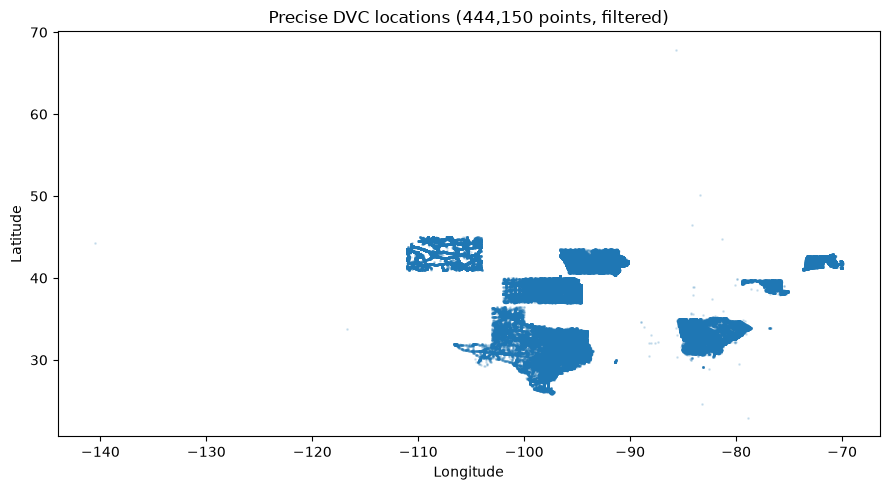

In [11]:
# Quick scatter of the clean points
clean = c.loc[in_bounds]
plt.figure(figsize=(9, 5))
plt.scatter(clean['Longitude'], clean['Latitude'], s=1, alpha=0.15)
plt.xlabel('Longitude'); plt.ylabel('Latitude')
plt.title(f'Precise DVC locations ({len(clean):,} points, filtered)')
plt.tight_layout()
plt.show()

## 5. Duplicate rows

In [12]:
dups = df.duplicated().sum()
print(f'Fully identical duplicate rows: {dups:,}  ({dups/len(df)*100:.2f}%)')
print(f'Rows involved in a duplicate group: {df.duplicated(keep=False).sum():,}')
df[df.duplicated(keep=False)].sort_values(list(df.columns)).head(6)

Fully identical duplicate rows: 4,543  (1.02%)


Rows involved in a duplicate group: 8,417


,state,date_time,time.decimal,month,county_name,lat_CountyCentroid,long_CountyCentroid,doy,Latitude,Longitude,week,sunrise,sunrise.decimal,sunset,sunset.decimal,timezone,state_abbreviation
row_id,,,,,,,,,,,,,,,,,
565413,Georgia,2015-01-08 07:26:00,7.433333,1,coweta,33.353345,-84.763355,8,33.495896,-84.740092,1,2015-01-08 07:44:47,7.746389,2015-01-08 17:48:33,17.809167,Eastern,GA
565416,Georgia,2015-01-08 07:26:00,7.433333,1,coweta,33.353345,-84.763355,8,33.495896,-84.740092,1,2015-01-08 07:44:47,7.746389,2015-01-08 17:48:33,17.809167,Eastern,GA
565691,Georgia,2015-01-21 18:24:00,18.400000,1,monroe,33.013825,-83.918706,21,33.098499,-83.833556,3,2015-01-21 07:38:16,7.637778,2015-01-21 17:57:42,17.961667,Eastern,GA
565692,Georgia,2015-01-21 18:24:00,18.400000,1,monroe,33.013825,-83.918706,21,33.098499,-83.833556,3,2015-01-21 07:38:16,7.637778,2015-01-21 17:57:42,17.961667,Eastern,GA
566087,Georgia,2015-02-07 20:13:00,20.216667,2,madison,34.127768,-83.209014,38,34.089894,-83.242987,5,2015-02-07 07:27:05,7.451389,2015-02-07 18:09:28,18.157778,Eastern,GA
566088,Georgia,2015-02-07 20:13:00,20.216667,2,madison,34.127768,-83.209014,38,34.089894,-83.242987,5,2015-02-07 07:27:05,7.451389,2015-02-07 18:09:28,18.157778,Eastern,GA


## 6. County / centroid placeholders

In [13]:
upper_counties = df.loc[df['county_name'].str.isupper(), 'county_name']
print('`county_name` upper-case placeholder values:')
print(upper_counties.value_counts() if len(upper_counties) else '(none)')
print()
print('Rows with missing county-centroid coords, by county_name:')
print(df.loc[df['lat_CountyCentroid'].isna(), 'county_name'].value_counts().head())

`county_name` upper-case placeholder values:
county_name
STATE_CENTROID    196
Name: count, dtype: int64

Rows with missing county-centroid coords, by county_name:
county_name
STATE_CENTROID    196
Name: count, dtype: int64


## 7. Temporal coverage

Date range : 1994-01-01 02:30:00 -> 2021-12-07 21:45:00
Unparseable date_time values: 0


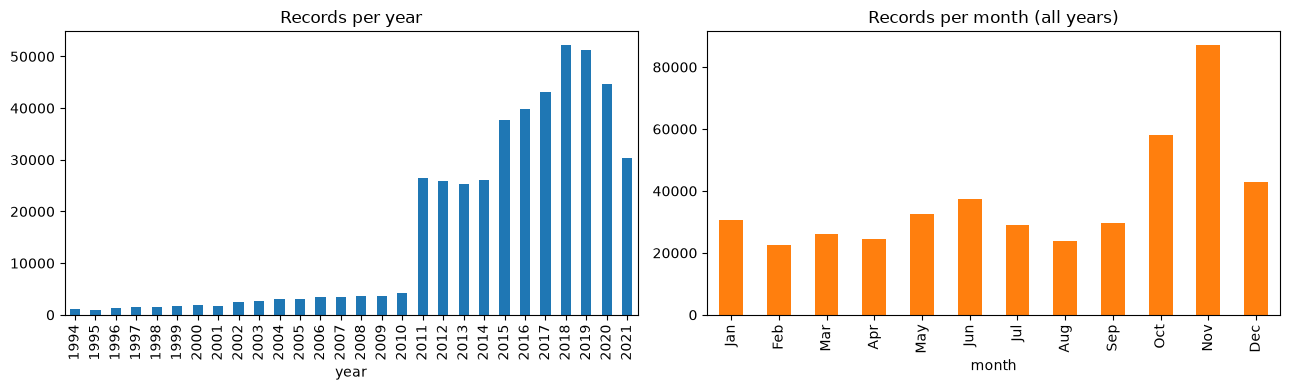


Month share of all records:
month
1      6.9
2      5.1
3      5.9
4      5.5
5      7.4
6      8.4
7      6.5
8      5.4
9      6.7
10    13.1
11    19.6
12     9.6
Name: proportion, dtype: float64


In [14]:
dt = pd.to_datetime(df['date_time'], errors='coerce')
print('Date range :', dt.min(), '->', dt.max())
print('Unparseable date_time values:', dt.isna().sum())

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
dt.dt.year.value_counts().sort_index().plot.bar(ax=ax[0])
ax[0].set_title('Records per year'); ax[0].set_xlabel('year')

month_order = df['month'].value_counts().sort_index()
month_order.index = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
month_order.plot.bar(ax=ax[1], color='tab:orange')
ax[1].set_title('Records per month (all years)'); ax[1].set_xlabel('month')
plt.tight_layout()
plt.show()

print('\nMonth share of all records:')
print((df['month'].value_counts(normalize=True).sort_index()*100).round(1))

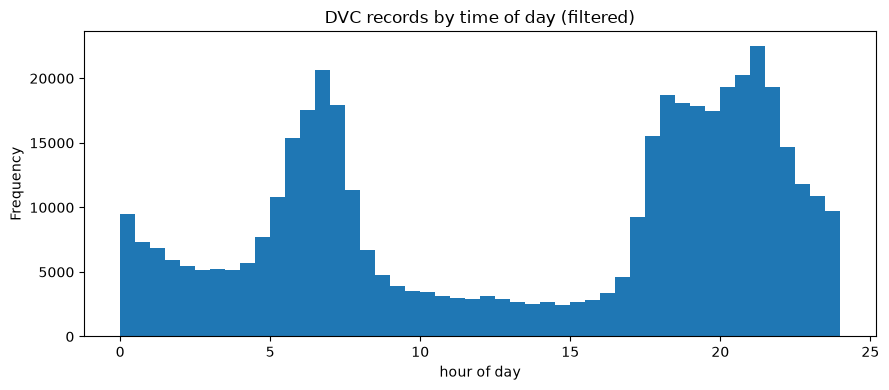

In [15]:
# Time of day (time.decimal = hour + fraction). Watch for the classic dawn/dusk peaks.
ax = df['time.decimal'].plot.hist(bins=48, figsize=(9, 4))
ax.set_xlabel('hour of day'); ax.set_title('DVC records by time of day (filtered)')
plt.tight_layout()
plt.show()

## 8. Summary of key findings

In [16]:
summary = {}
summary['rows']            = len(df)
summary['cols']            = df.shape[1]
summary['n_states']        = df['state'].nunique()
summary['states']          = ', '.join(sorted(df['state_abbreviation'].unique()))
summary['pct_both_latlon'] = round(has_both.mean()*100, 2)
summary['pct_in_us_box']   = round(in_bounds.mean()*100, 2)
summary['sign_fixable']    = int((fixed & ~in_bounds).sum())
summary['corrupt_coords']  = int((~in_bounds & ~fixed).sum())
summary['dup_rows']        = int(df.duplicated().sum())
summary['date_min']        = str(dt.min())
summary['date_max']        = str(dt.max())
top_month = df['month'].value_counts(normalize=True).idxmax()
summary['peak_month']      = f"{top_month} ({df['month'].value_counts(normalize=True).max()*100:.1f}%)"

for k, v in summary.items():
    print(f'{k:18}: {v}')

rows              : 444418
cols              : 17
n_states          : 9
states            : CT, GA, IA, KS, MA, MD, SC, TX, WY
pct_both_latlon   : 100.0
pct_in_us_box     : 99.94
sign_fixable      : 38
corrupt_coords    : 230
dup_rows          : 4543
date_min          : 1994-01-01 02:30:00
date_max          : 2021-12-07 21:45:00
peak_month        : 11 (19.6%)


| # | Finding |
|---|---------|
| Filter | Kept 9 states (CT, MD, IA, SC, WY, TX, KS, MA, GA) and dropped every row missing precise `Latitude`/`Longitude`. |
| Size | **444,418 rows × 17 columns** (from 1,012,465). |
| **Lat/Lon coverage** | **100%** of rows have both precise `Latitude` and `Longitude` (by construction). |
| **NaN by column** | `Latitude`/`Longitude` now 0% missing. Residual NaNs only in `lat_CountyCentroid`/`long_CountyCentroid` for `STATE_CENTROID` rows. |
| Coordinate quality | See Section 4 — a slice of points still fall outside the plausible US box, mostly a **dropped negative sign on Longitude** (recoverable); a handful are genuinely corrupt. Clean before mapping. |
| **Duplicates** | See Section 5 for the fully-identical-row count on the filtered data. |
| Seasonality | Autumn peak persists — see `peak_month` in the computed summary above. |

Exact numbers are printed by the computed-summary cell directly above and by each section's cells.

## 9. Cleaning — de-duplicate & confirm exact-coordinate coverage per state

Drop fully identical rows, write `DVC_data_filtered_clean.csv`, then report per state how many
records have precise `Latitude` / `Longitude` (expected: all of them).

In [17]:
# --- Remove duplicate rows -------------------------------------------------
before = len(df)
df_clean = df.drop_duplicates().reset_index(drop=True)
after = len(df_clean)
print(f'rows before : {before:,}')
print(f'rows after  : {after:,}')
print(f'removed     : {before - after:,}  ({(before - after) / before * 100:.2f}%)')
print(f'duplicates remaining: {df_clean.duplicated().sum()}')

# Write cleaned dataset
OUT_PATH = 'DVC_data_filtered_clean.csv'
df_clean.to_csv(OUT_PATH, index_label='row_id')
print(f'\nwrote {OUT_PATH}')

rows before : 444,418
rows after  : 439,875
removed     : 4,543  (1.02%)


duplicates remaining: 0



wrote DVC_data_filtered_clean.csv


In [18]:
# Which states have exact (precise) Latitude & Longitude — computed on the de-duplicated data
has_both_c = df_clean['Latitude'].notna() & df_clean['Longitude'].notna()

state_coords = (df_clean.assign(has_exact_coords=has_both_c)
                .groupby('state')
                .agg(records=('state', 'size'),
                     n_with_exact_coords=('has_exact_coords', 'sum'),
                     pct_with_exact_coords=('has_exact_coords', lambda s: round(s.mean() * 100, 1)))
                .sort_values('pct_with_exact_coords', ascending=False))

def bucket(p):
    if p >= 50:  return 'has coords'
    if p > 0:    return 'partial'
    return 'none'
state_coords['coverage'] = state_coords['pct_with_exact_coords'].map(bucket)

print('States WITH exact coordinates (>=50% of rows):')
print('  ' + ', '.join(state_coords.index[state_coords.coverage == 'has coords']))
print('\nPartial:')
print('  ' + (', '.join(state_coords.index[state_coords.coverage == 'partial']) or '(none)'))
print('\nEffectively NONE (0%):')
print('  ' + (', '.join(state_coords.index[state_coords.coverage == 'none']) or '(none)'))
print()
state_coords

States WITH exact coordinates (>=50% of rows):
  Connecticut, Georgia, Iowa, Kansas, Maryland, Massachusetts, South Carolina, Texas, Wyoming

Partial:
  (none)

Effectively NONE (0%):
  (none)



,records,n_with_exact_coords,pct_with_exact_coords,coverage
state,,,,
Connecticut,7531,7531,100.0,has coords
Georgia,70663,70663,100.0,has coords
Iowa,76636,76636,100.0,has coords
Kansas,99790,99790,100.0,has coords
Maryland,16616,16616,100.0,has coords
Massachusetts,37330,37330,100.0,has coords
South Carolina,8644,8644,100.0,has coords
Texas,68345,68345,100.0,has coords
Wyoming,54320,54320,100.0,has coords


### Notes

- **Filtering** kept only the 9 requested states and only rows where **both** `Latitude` and `Longitude` are present (37,010 rows dropped for missing coords).
- **Deduplication** here removes only *fully identical* rows (all 17 fields equal).
- **"Has exact coordinates"** = both `Latitude` and `Longitude` present. Every state should now sit at ~100% (small shortfalls, if any, come only from residual county-centroid gaps, not the precise coords).
- This step does **not** fix the sign-flipped / corrupt coordinate values (Section 4) — handle those downstream when building the spatial layer.